# EDA — `lexdata.procesos_alimentos`
CSJ Rama Judicial · procesos de alimentos (familia)

## 0 · Setup

In [1]:
# ── Dependencias ────────────────────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

# ── Estilo ──────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# ── Conexión PostgreSQL via .env ─────────────────────────────────────────────
load_dotenv()  # carga .env desde la carpeta del notebook
DB_URL = (
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)
engine = create_engine(DB_URL)

def sql(query, **kwargs):
    with engine.connect() as con:
        return pd.read_sql(text(query), con, **kwargs)

print("✅ Conexión lista:", DB_URL.split("@")[-1])


✅ Conexión lista: localhost:5432/lexdata


## 1 · Vista general

In [2]:
df = sql("SELECT * FROM lexdata.procesos_alimentos")
print(f"Shape: {df.shape}")
print(f"Municipios únicos : {df['municipio'].nunique()}")
print(f"Años              : {sorted(df['anio'].dropna().unique().tolist())}")
df.head()


Shape: (229300, 8)
Municipios únicos : 1
Años              : [2020, 2021, 2022, 2023, 2024, 2025]


,id,municipio,departamento,anio,cantidad,tipo_ciclo,fuente,created_at
0,1,SIN_DATO,None,2024,1.0,ALIMENTOS,CSJ — Procesos Alimentos (rgxm-mmea),2026-05-25 14:21:50.642990
1,2,SIN_DATO,None,2025,1.0,ALIMENTOS,CSJ — Procesos Alimentos (rgxm-mmea),2026-05-25 14:21:50.642990
2,3,SIN_DATO,None,2020,1.0,ALIMENTOS,CSJ — Procesos Alimentos (rgxm-mmea),2026-05-25 14:21:50.642990
3,4,SIN_DATO,None,2021,1.0,ALIMENTOS,CSJ — Procesos Alimentos (rgxm-mmea),2026-05-25 14:21:50.642990
4,5,SIN_DATO,None,2023,1.0,ALIMENTOS,CSJ — Procesos Alimentos (rgxm-mmea),2026-05-25 14:21:50.642990


In [3]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,229300.0,NaN,NaN,NaN,114650.5,1.0,57325.75,114650.5,171975.25,229300.0,66193.3527
municipio,229300,1,SIN_DATO,229300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departamento,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
anio,229300.0,NaN,NaN,NaN,2022.435988,2020.0,2021.0,2022.0,2024.0,2025.0,1.690156
cantidad,229300.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,0.0
tipo_ciclo,229300,1,ALIMENTOS,229300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuente,229300,1,CSJ — Procesos Alimentos (rgxm-mmea),229300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_at,229300,NaN,NaN,NaN,2026-05-25 14:22:30.222305280,2026-05-25 14:21:50.642990,2026-05-25 14:21:50.642990080,2026-05-25 14:22:30.222305536,2026-05-25 14:23:09.801620992,2026-05-25 14:23:09.801621,NaN


## 2 · Nulos

In [4]:
nulos = df.isnull().sum().rename("nulos")
pct   = (df.isnull().mean() * 100).round(2).rename("pct_%")
display(pd.concat([nulos, pct], axis=1))


,nulos,pct_%
id,0,0.0
municipio,0,0.0
departamento,229300,100.0
anio,0,0.0
cantidad,0,0.0
tipo_ciclo,0,0.0
fuente,0,0.0
created_at,0,0.0


## 3 · Procesos por año

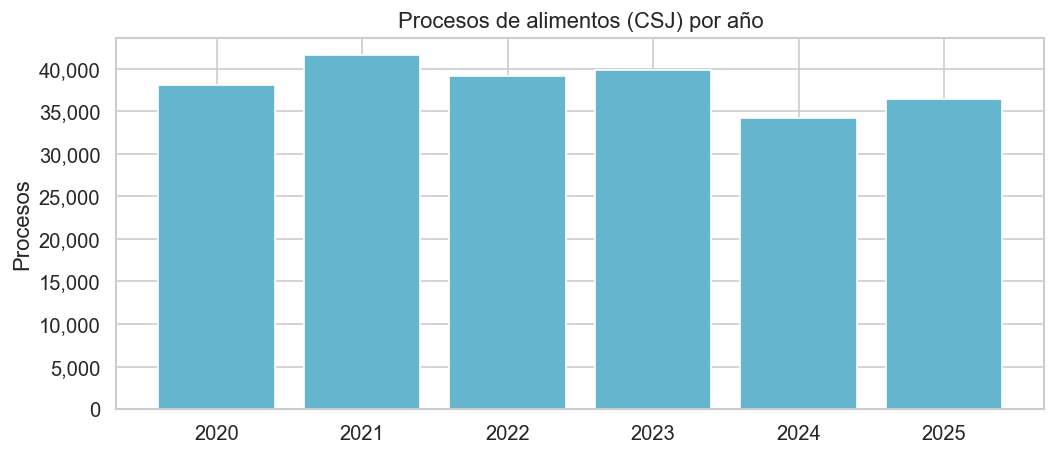

 anio  cantidad
 2020   38048.0
 2021   41568.0
 2022   39168.0
 2023   39882.0
 2024   34148.0
 2025   36486.0


In [5]:
anio_cnt = df.groupby("anio")["cantidad"].sum().reset_index().sort_values("anio")
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(anio_cnt["anio"].astype(str), anio_cnt["cantidad"], color="#64B5CD")
ax.set_title("Procesos de alimentos (CSJ) por año")
ax.set_ylabel("Procesos")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout(); plt.show()
print(anio_cnt.to_string(index=False))


## 4 · Top 25 municipios

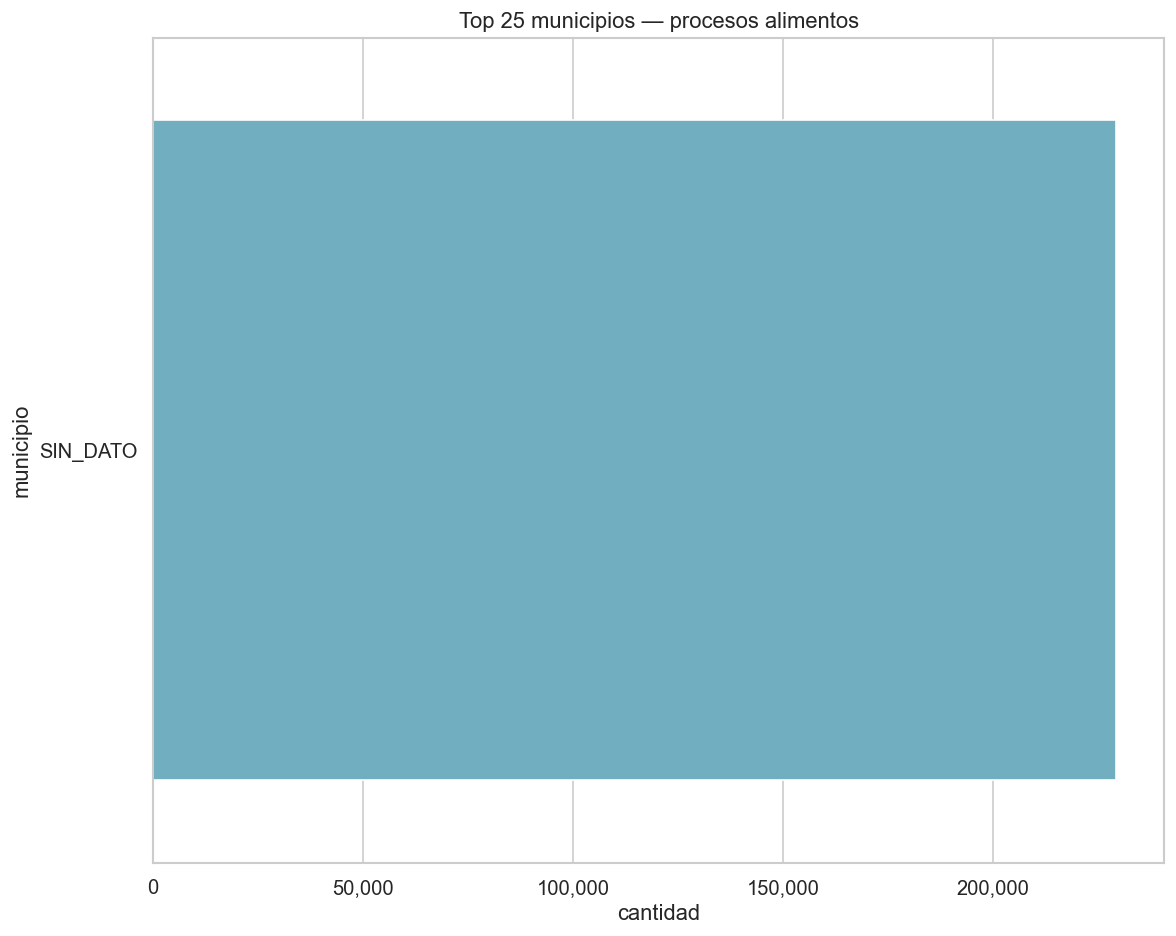

In [6]:
top_mun = df.groupby("municipio")["cantidad"].sum().nlargest(25).reset_index()
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=top_mun, y="municipio", x="cantidad", ax=ax, color="#64B5CD")
ax.set_title("Top 25 municipios — procesos alimentos")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout(); plt.show()


## 5 · Departamentos

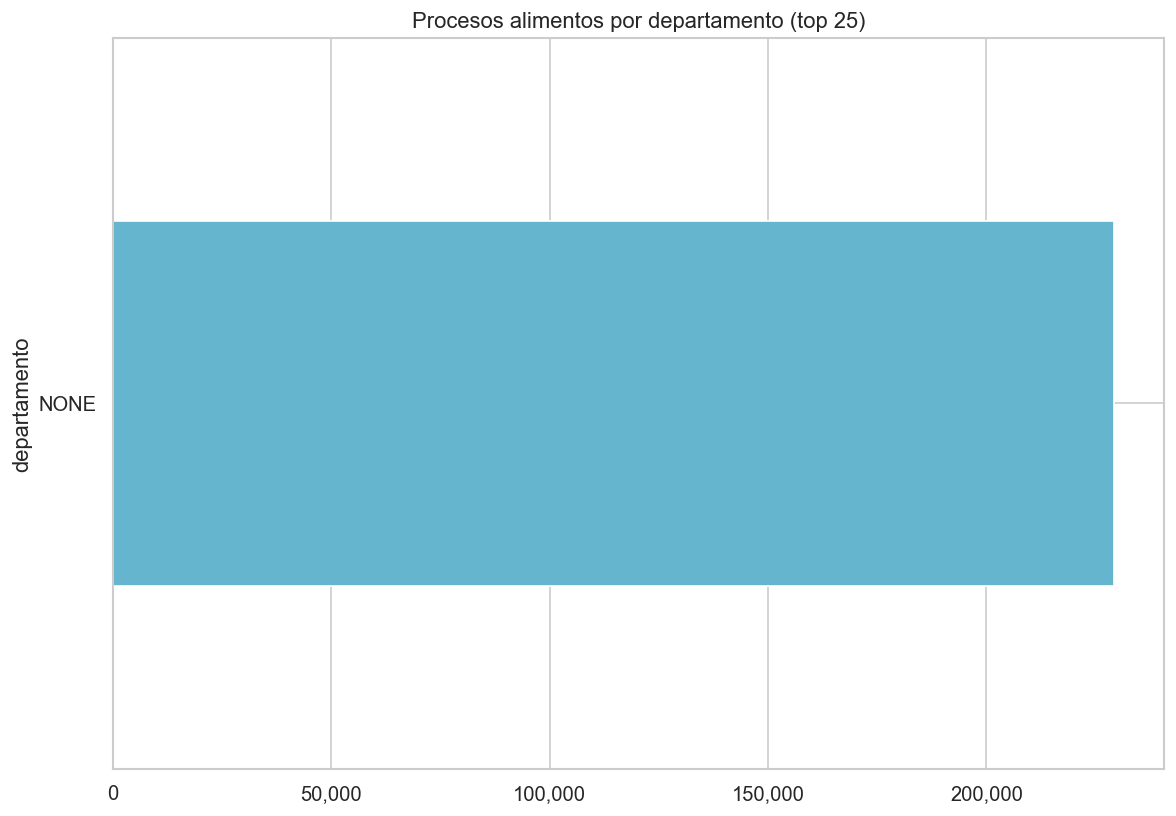

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df.columns = df.columns.str.strip().str.lower()

df["departamento"] = (
    df["departamento"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df = df[df["departamento"].notna()]

dep_cnt = (
    df.groupby("departamento")["cantidad"]
    .sum()
    .sort_values(ascending=False)
)

top = dep_cnt.head(25)

if top.empty:
    print("No hay datos para graficar")
else:
    fig, ax = plt.subplots(figsize=(10, 7))

    top.plot(
        kind="barh",
        ax=ax,
        color="#64B5CD"
    )

    ax.set_title("Procesos alimentos por departamento (top 25)")
    ax.invert_yaxis()

    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
    )

    plt.tight_layout()
    plt.show()

## 6 · Tendencia temporal — top 5 municipios

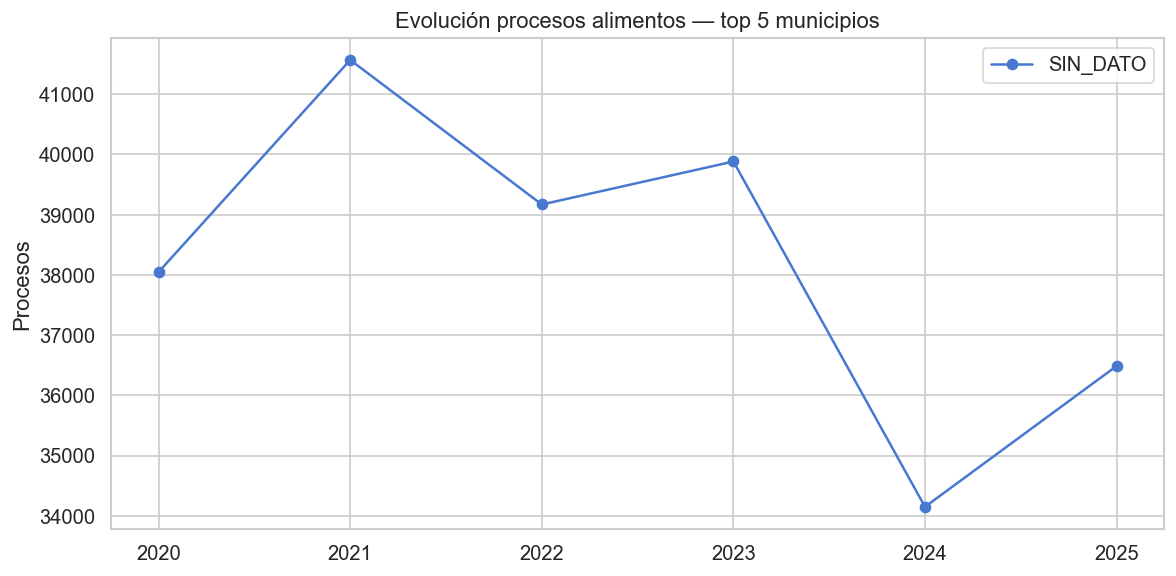

In [9]:
top5 = df.groupby("municipio")["cantidad"].sum().nlargest(5).index
df_top = df[df["municipio"].isin(top5)].groupby(["anio","municipio"])["cantidad"].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for mun, grp in df_top.groupby("municipio"):
    ax.plot(grp["anio"].astype(str), grp["cantidad"], marker="o", label=mun)
ax.set_title("Evolución procesos alimentos — top 5 municipios")
ax.legend(loc="upper right"); ax.set_ylabel("Procesos")
plt.tight_layout(); plt.show()


## 7 · Heatmap top 15 municipios × año

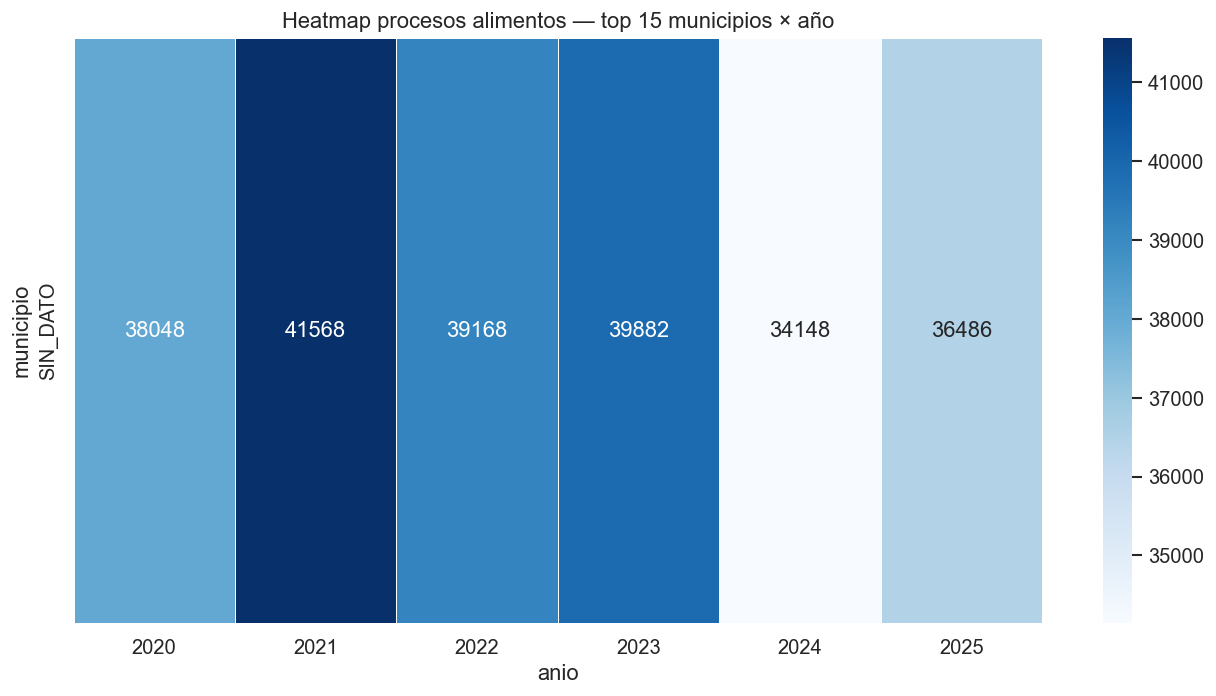

In [11]:
top15 = df.groupby("municipio")["cantidad"].sum().nlargest(15).index

pivot = (
    df[df["municipio"].isin(top15)]
    .pivot_table(
        index="municipio",
        columns="anio",
        values="cantidad",
        aggfunc="sum",
        fill_value=0
    )
)

pivot = pivot.fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(11, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.4,
    ax=ax
)

ax.set_title("Heatmap procesos alimentos — top 15 municipios × año")

plt.tight_layout()
plt.show()

## 8 · Proporción respecto al total nacional por año

In [12]:
total_nac = df.groupby("anio")["cantidad"].sum().rename("total_nacional")
dep_anio  = df.groupby(["departamento","anio"])["cantidad"].sum().reset_index()
dep_anio  = dep_anio.merge(total_nac, on="anio")
dep_anio["pct_nacional"] = (dep_anio["cantidad"] / dep_anio["total_nacional"] * 100).round(2)
top_dep = dep_anio.groupby("departamento")["cantidad"].sum().nlargest(8).index
display(dep_anio[dep_anio["departamento"].isin(top_dep)].sort_values(["departamento","anio"]))


,departamento,anio,cantidad,total_nacional,pct_nacional
0,NONE,2020,38048.0,38048.0,100.0
1,NONE,2021,41568.0,41568.0,100.0
2,NONE,2022,39168.0,39168.0,100.0
3,NONE,2023,39882.0,39882.0,100.0
4,NONE,2024,34148.0,34148.0,100.0
5,NONE,2025,36486.0,36486.0,100.0
